# 实验十七：高级形态学——击中击不中与形态学重建

**实验目的：**
深入理解形态学的高级应用，掌握利用特定的几何结构精确提取局部图案，以及基于掩模的拓扑重建技巧。

###  实际应用场景说明
在工业检测和医学影像处理中，我们经常遇到以下棘手问题，而这些正是高级形态学的用武之地：
1. **击中击不中变换 (Hit-or-Miss)：** * **应用场景：** PCB（印制电路板）缺陷检测。我们需要在错综复杂的电路图中，精准找出“十字交叉点”或“特定角度的拐角”，以判断走线是否短路或断路。它可以精确匹配你想要的任意像素排列模式。
2. **形态学重建 (Morphological Reconstruction)：**
   * **应用场景：** 医学显微细胞计数。显微镜视野边缘的细胞往往是被切断的（不完整），如果把它们计入总数会影响医学化验结果的准确性。通过“清除边界对象”的重建操作，我们可以只保留完全位于视野内部的健康细胞。
   * **应用场景：** 视网膜血管提取。普通的开运算在去除噪点时，会把细小的血管也弄断。而“形态学重建”可以利用断裂的血管作为“种子”，顺着原来的血管走向重新生长，完美恢复血管网络而不引入周围的噪点。


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1. 击中击不中变换 (Hit-or-Miss Transform)
普通腐蚀只看前景（白点），而击中击不中变换不仅要求前景匹配，还要求**背景（黑点）也完全匹配**。
在 OpenCV 中，结构元素 Kernel 的定义很有趣：
* `1` 表示该位置必须是前景（白色）
* `-1` 表示该位置必须是背景（黑色）
* `0` 表示“不关心”（Do not care，黑白都可以）


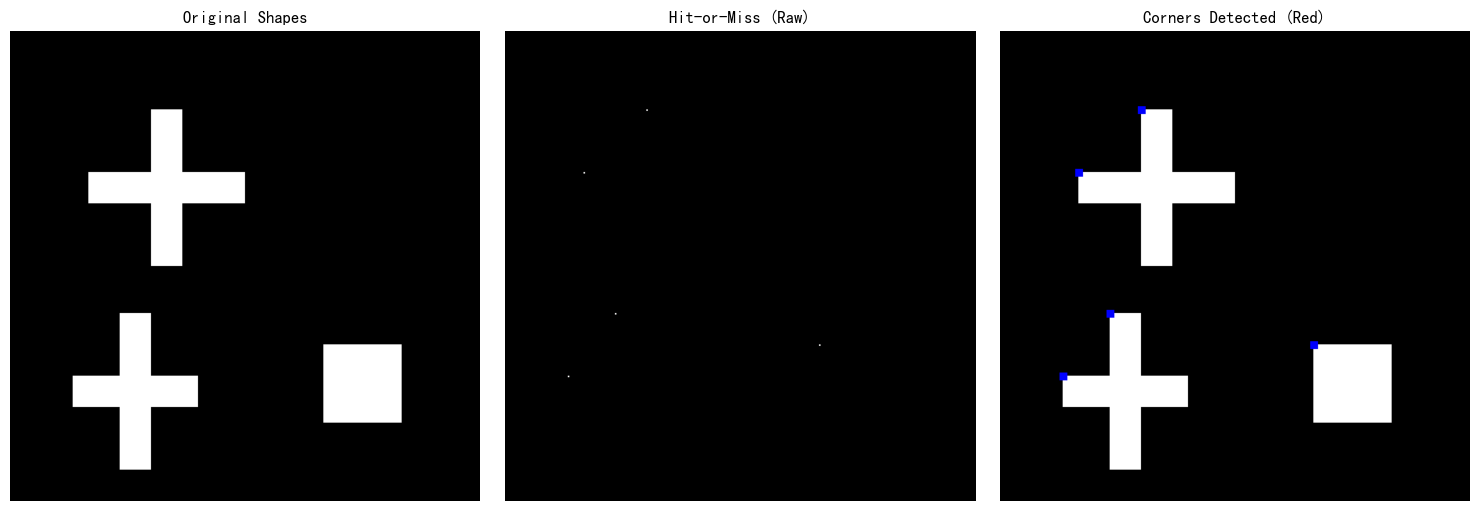

💡 结论：不管是什么形状，算法精准地抓住了所有物体的‘左上角’那个特殊的像素排列模式！


In [6]:
# 自动生成一张包含多种形状的测试图
img_shapes = np.zeros((300, 300), dtype=np.uint8)
# 画一个十字形
img_shapes[50:150, 90:110] = 255
img_shapes[90:110, 50:150] = 255
# 画一个实心正方形
img_shapes[200:250, 200:250] = 255
# 画一个大十字形
img_shapes[180:280, 70:90] = 255
img_shapes[220:240, 40:120] = 255

# 任务：我们要精确定位所有形状的【左上角顶点】
# 设计一个寻找左上角的 Kernel：
# 背景 背景 背景
# 背景 前景 前景
# 背景 前景 不关心
kernel_corner = np.array([
    [-1, -1, -1],
    [-1,  1,  1],
    [-1,  1,  0]
], dtype=np.int32)

# 执行击中击不中变换
hit_miss_result = cv2.morphologyEx(img_shapes, cv2.MORPH_HITMISS, kernel_corner)

# 为了可视化，我们将找到的点膨胀一下标成红色，叠加到原图上
result_display = cv2.cvtColor(img_shapes, cv2.COLOR_GRAY2BGR)
hit_miss_dilated = cv2.dilate(hit_miss_result, np.ones((5,5), np.uint8))
result_display[hit_miss_dilated > 0] = [0, 0, 255] # 红色标记

show_images([img_shapes, hit_miss_result, result_display], 
            ["Original Shapes", "Hit-or-Miss (Raw)", "Corners Detected (Red)"])
print("💡 结论：不管是什么形状，算法精准地抓住了所有物体的‘左上角’那个特殊的像素排列模式！")


## 2. 形态学重建：测地膨胀 (Geodesic Dilation)
形态学重建需要两张图：
1. **标记图 (Marker)：** 包含生长的“种子”。
2. **掩模图 (Mask)：** 限制种子生长的“边界”（通常是原图）。
核心原理：对标记图进行膨胀，但每次膨胀后都要和掩模图进行**按位与 (Bitwise AND)** 操作。反复迭代，直到图像不再发生任何变化为止。


In [7]:
def morphological_reconstruction(marker, mask):
    """手工实现形态学重建算法"""
    kernel = np.ones((3, 3), np.uint8)
    # 防止意外修改原图，做个拷贝
    current_marker = marker.copy()

    while True:
        # 1. 膨胀标记图
        expanded = cv2.dilate(current_marker, kernel)
        # 2. 与掩模图取交集 (限制生长范围)
        expanded = cv2.bitwise_and(expanded, mask)
        # 3. 检查是否达到收敛 (图像不再变化)
        if np.array_equal(current_marker, expanded):
            break
        current_marker = expanded

    return current_marker

print("✅ 形态学重建核心算法定义完成！")


✅ 形态学重建核心算法定义完成！


## 3. 重建实战：清除触碰图像边界的物体 (细胞计数预处理)
假设我们在显微镜下拍到了一堆细胞，有的在正中间，有的被镜头边缘切成了两半。
如果我们想统计健康完整细胞的平均面积，就必须先把碰到边缘的残缺细胞去掉！


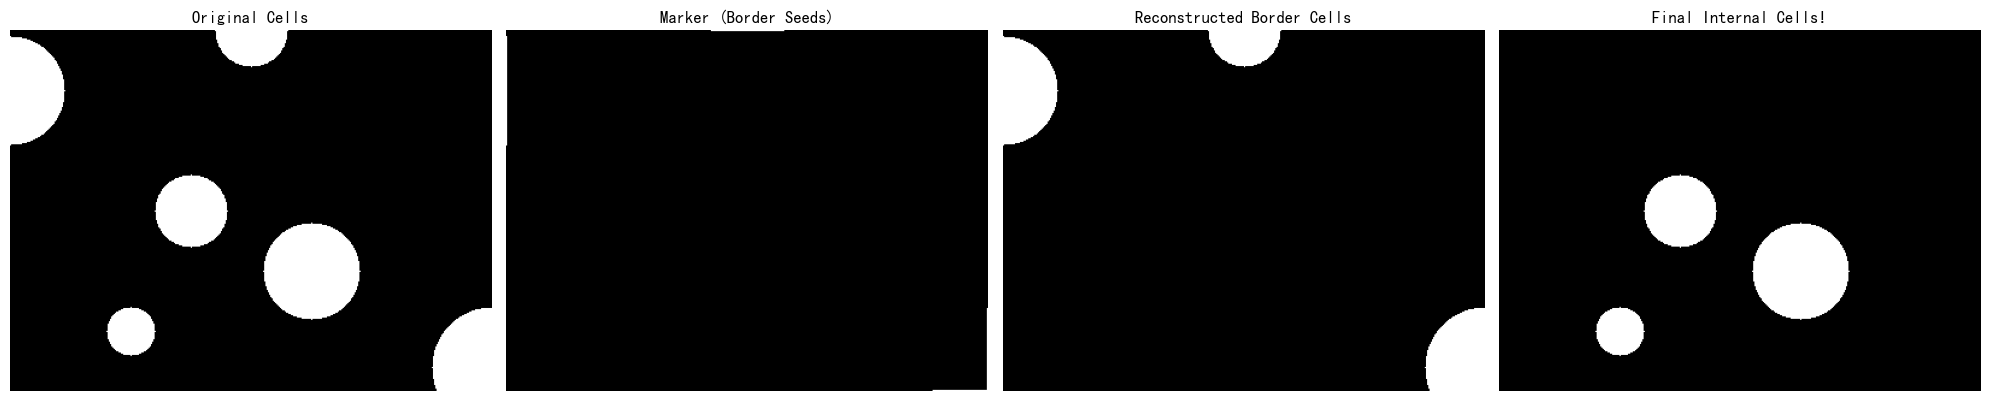

In [8]:
# 自动生成模拟细胞图像
img_cells = np.zeros((300, 400), dtype=np.uint8)
# 完整的细胞 (中间)
cv2.circle(img_cells, (150, 150), 30, 255, -1)
cv2.circle(img_cells, (250, 200), 40, 255, -1)
cv2.circle(img_cells, (100, 250), 20, 255, -1)
# 碰到边缘的残缺细胞
cv2.circle(img_cells, (0, 50), 45, 255, -1)     # 左边缘
cv2.circle(img_cells, (200, 0), 30, 255, -1)    # 上边缘
cv2.circle(img_cells, (400, 280), 50, 255, -1)  # 右边缘

# 1. 制作掩模图 Mask (就是原图)
mask = img_cells.copy()

# 2. 制作标记图 Marker
# 我们只保留原图四个边缘的像素作为“毒种子”，其余全部涂黑
marker = np.zeros_like(img_cells)
marker[0, :] = img_cells[0, :]         # 顶边
marker[-1, :] = img_cells[-1, :]       # 底边
marker[:, 0] = img_cells[:, 0]         # 左边
marker[:, -1] = img_cells[:, -1]       # 右边

# 3. 执行形态学重建 (毒种子会在接触到边缘的细胞内部疯狂蔓延，直到填满它们)
border_objects = morphological_reconstruction(marker, mask)

# 4. 原图减去边缘对象，完美留下内部完整对象！
internal_cells = cv2.subtract(mask, border_objects)

show_images([img_cells, marker, border_objects, internal_cells], 
            ["Original Cells", "Marker (Border Seeds)", "Reconstructed Border Cells", "Final Internal Cells!"],
            figsize=(20, 5))


## 4. 终极应用：完美孔洞填充 (Perfect Hole Filling)

**痛点：** 传统的“闭运算”虽然能填补细小孔洞，但如果孔洞太大，使用巨大的 Kernel 会严重破坏物体原本的外部轮廓。
**救星：** 形态学重建！它能填满任意大小的内部孔洞，同时 **100% 完美保留物体外部的复杂边缘**。

我们将通过两个硬核例子来验证：
1. **不规则陨石/矿石检测：** 边缘极其参差不齐，内部有大大小小的空洞。
2. **残缺字符/车牌修复：** 提取带有闭合区域的字母（如 O、P、B、8、0），填实内部以便于 OCR 识别。


 例子 1：复杂边界与巨大孔洞的博弈


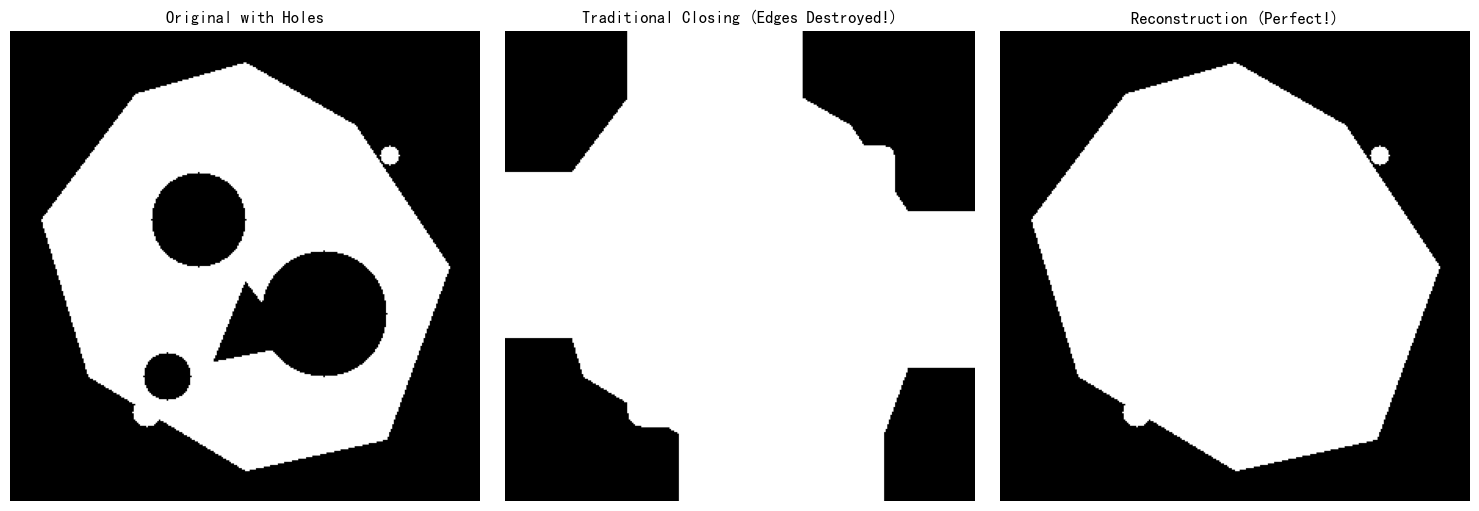


 例子 2：字符内部结构提取与填充


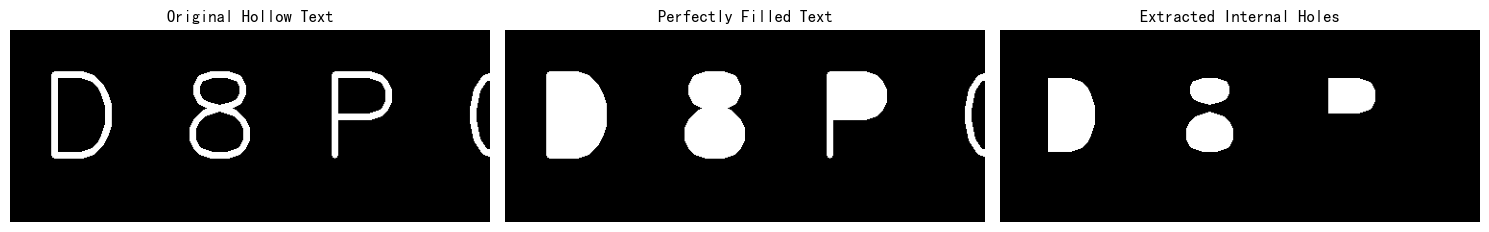

In [9]:
# --- 辅助函数：完美孔洞填充算法 ---
def fill_holes_perfectly(image):
    # 1. 制作掩模 (Mask)：原图的反色
    mask = cv2.bitwise_not(image)

    # 2. 制作标记 (Marker)：只保留掩模最外侧一圈的像素作为种子，其余全黑
    marker = np.zeros_like(mask)
    marker[0, :] = mask[0, :]
    marker[-1, :] = mask[-1, :]
    marker[:, 0] = mask[:, 0]
    marker[:, -1] = mask[:, -1]

    # 3. 形态学重建 (外部背景会被完全填满，但进不到孔洞里面)
    # 这里复用我们之前手工写的 morphological_reconstruction 函数
    reconstructed_background = morphological_reconstruction(marker, mask)

    # 4. 将填满的背景再次取反，得到的就是完美填充孔洞后的前景！
    filled_image = cv2.bitwise_not(reconstructed_background)
    return filled_image

# ==========================================
# 例子 1：不规则“陨石”截面图 (边缘参差不齐，含巨大孔洞)
# ==========================================
img_meteorite = np.zeros((300, 300), dtype=np.uint8)
# 画一个边缘长满“尖刺”的复杂多边形
pts = np.array([[150, 20], [220, 60], [280, 150], [240, 260], [150, 280], [50, 220], [20, 120], [80, 40]], np.int32)
cv2.fillPoly(img_meteorite, [pts], 255)
# 强行在多边形边缘加上一些毛刺
for i in range(20):
    cv2.circle(img_meteorite, (np.random.randint(50, 250), np.random.randint(50, 250)), np.random.randint(5, 15), 255, -1)

# 在内部挖几个大大小小的洞！
cv2.circle(img_meteorite, (120, 120), 30, 0, -1)
cv2.circle(img_meteorite, (200, 180), 40, 0, -1)
cv2.circle(img_meteorite, (100, 220), 15, 0, -1)
pts_hole = np.array([[150, 160], [180, 200], [130, 210]], np.int32)
cv2.fillPoly(img_meteorite, [pts_hole], 0)

# 尝试用传统闭运算修复 (需要极大的 Kernel 才能填满半径 40 的大洞)
kernel_huge = np.ones((85, 85), np.uint8)
meteorite_closed = cv2.morphologyEx(img_meteorite, cv2.MORPH_CLOSE, kernel_huge)

# 用我们的完美孔洞填充算法修复
meteorite_perfect = fill_holes_perfectly(img_meteorite)

print(" 例子 1：复杂边界与巨大孔洞的博弈")
show_images([img_meteorite, meteorite_closed, meteorite_perfect], 
            ["Original with Holes", "Traditional Closing (Edges Destroyed!)", "Reconstruction (Perfect!)"])


# ==========================================
# 例子 2：空心字符/车牌修复 (OCR 预处理)
# ==========================================
img_text = np.zeros((200, 500), dtype=np.uint8)
# 画几个带有内部孔洞的空心字母和数字
cv2.putText(img_text, "D 8 P 0", (30, 130), cv2.FONT_HERSHEY_SIMPLEX, 4, 255, 5)

# 用我们的完美孔洞填充算法填满它们
text_filled = fill_holes_perfectly(img_text)

# 提取孔洞本身 (填充后的图 减去 原始空心图)
just_holes = cv2.subtract(text_filled, img_text)

print("\n 例子 2：字符内部结构提取与填充")
show_images([img_text, text_filled, just_holes], 
            ["Original Hollow Text", "Perfectly Filled Text", "Extracted Internal Holes"])
